In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            x_stat = gwf.Xstat_timemax(loglike_obj.signal, h_temp)
            out[i] = float(x_stat.get() if hasattr(x_stat, 'get') else x_stat)
        except Exception:
            pass
    return out


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris1_detsnr/int_3mth_new'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.021095  ,  0.620815  ,  0.852575  ,  0.424375  ,  0.315185  ],
        [ 0.02775562,  0.6313422 ,  0.86802384,  0.42649511,  0.32474373],
        [ 0.00482752,  0.62550218,  0.85045833,  0.42277861,  0.30597206],
        ...,
        [ 0.87557937, -0.70590679,  0.35204635,  0.54843256,  0.03072826],
        [ 0.70302662,  0.6219207 ,  0.11938313,  1.12106521,  1.55490294],
        [ 0.45327341,  0.47861082,  0.15122885, -0.14685762,  0.4054292 ]])]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([6.81797784, 5.01722889, 5.53725886, ...,       -inf,       -inf,
              -inf])]

In [7]:
sampler.now_covariances

[array([[ 1.40993266e-01,  1.97726697e-02, -2.40218614e-02,
         -1.51318352e-02,  5.24272807e-05],
        [ 1.97726697e-02,  2.52038965e-01,  1.45203355e-02,
          3.86386560e-03,  9.03722892e-03],
        [-2.40218614e-02,  1.45203355e-02,  2.13176324e-01,
          2.43718261e-03, -2.79813892e-02],
        [-1.51318352e-02,  3.86386560e-03,  2.43718261e-03,
          3.24545763e-01,  4.90021738e-03],
        [ 5.24272807e-05,  9.03722892e-03, -2.79813892e-02,
          4.90021738e-03,  1.96068336e-01]])]

In [8]:
np.argmax(logden_list)

0

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[5.616876  , 1.1104075 , 0.88827675, 9.273125  , 0.2945555 ]])

In [10]:
log_density(maxld_pt1)

array([6.81797784])

In [11]:
log_density([param_true])

array([10.51843535])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

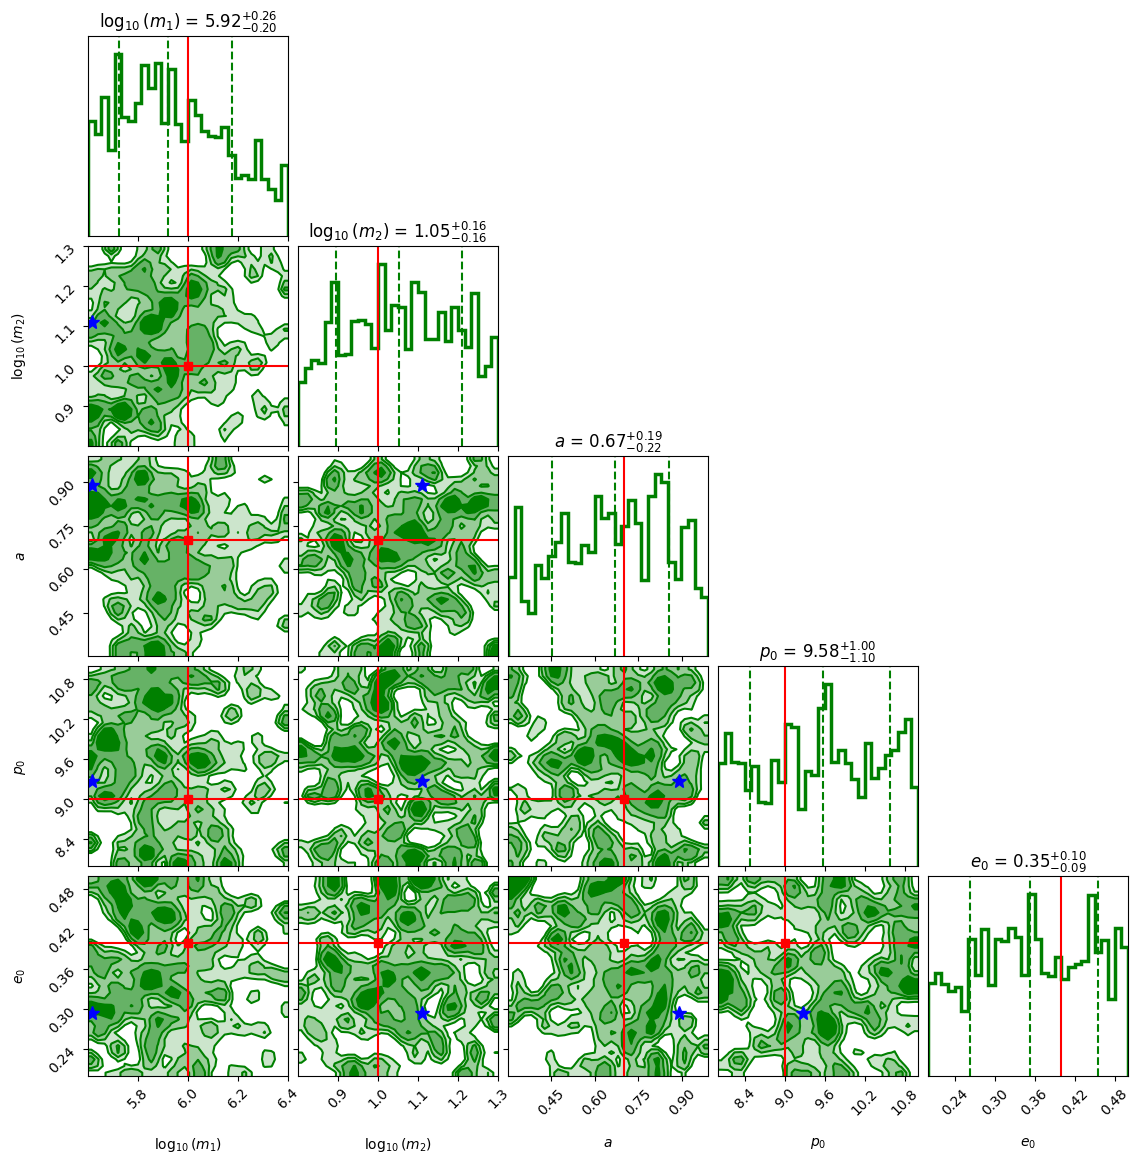

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
np.sort(logden_list)

array([[      -inf,       -inf,       -inf, ..., 6.37849817, 6.63709478,
        6.81797784]])

In [16]:
top10_idx = np.argsort(logden_list).flatten()[-10:][::-1]
top10_idx

array([   0,  601,  994, 1380,  205,  252,  133,  397,   28,  800])

In [17]:
top10_pts = prior_transform(proc_pt[0][top10_idx])
top10_pts

array([[5.616876  , 1.1104075 , 0.88827675, 9.273125  , 0.2945555 ],
       [5.60107684, 1.04684322, 0.88491352, 9.00519134, 0.31774836],
       [5.78120572, 1.02410944, 0.74614916, 9.3949444 , 0.39922649],
       [5.80172936, 1.16245684, 0.83046831, 9.08077353, 0.44246646],
       [5.6508152 , 1.10497924, 0.88617466, 9.20329644, 0.28559911],
       [5.71131568, 1.1175617 , 0.87300387, 9.2463747 , 0.29507254],
       [5.6416457 , 1.11049263, 0.88026445, 9.26798616, 0.27999218],
       [5.60670601, 1.08950809, 0.89588451, 9.19505837, 0.29812514],
       [5.62893287, 1.11537542, 0.88134371, 9.33962446, 0.28815636],
       [5.78368759, 1.24618728, 0.87202165, 8.26905394, 0.34143194]])

In [18]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       

In [19]:
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        
true_params = np.array([6.0, 1.0, 0.7, 9.0, 0.4])
ndim = 5                                                                                                                                                                           
            

In [20]:
import matplotlib.pyplot as plt

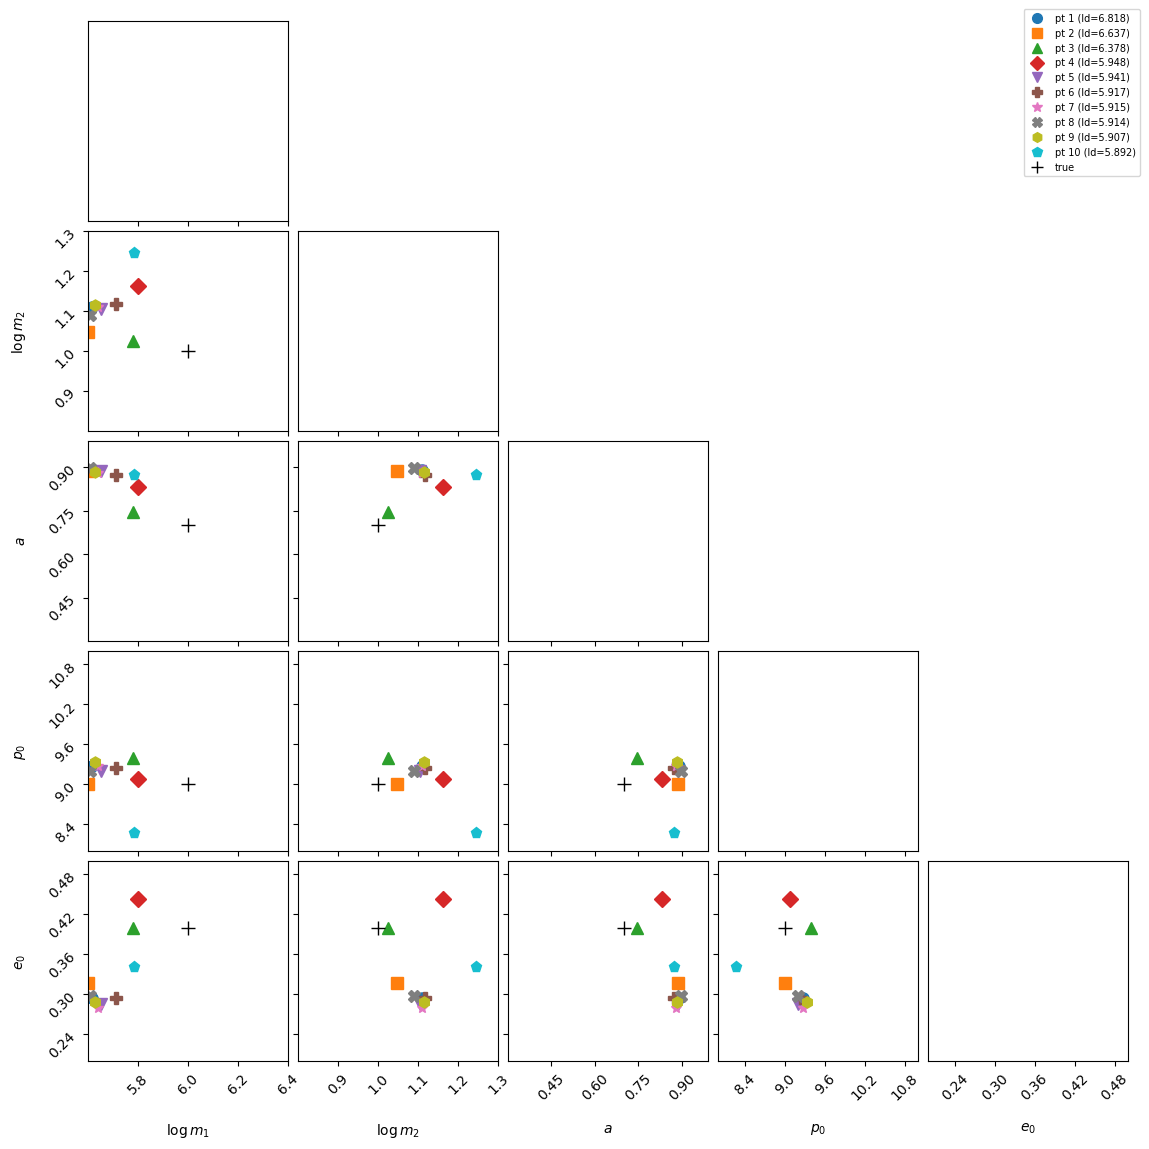

In [21]:
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers_list = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

all_pts = np.vstack([top10_pts, [true_params]])
fig = corner.corner(all_pts, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False, plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0, lw=0))

for i, pt in enumerate(top10_pts):
    corner.overplot_points(fig, pt.reshape(1, -1), color=_cycle[i % len(_cycle)], marker=markers_list[i], ms=8)

corner.overplot_points(fig, np.array([true_params]), color='black', marker='+', ms=10)

# Re-enforce ranges
axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
ld_vals = np.concatenate(logden_list)[top10_idx]
handles = [Line2D([0],[0], color=_cycle[i % len(_cycle)], marker=markers_list[i], ls='', ms=7,
                label=f"pt {i+1} (ld={ld_vals[i]:.3f})")
            for i in range(10)]
handles.append(Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'))
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=7)
plt.show()

# connection plot

In [22]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[5.616876  , 1.1104075 , 0.88827675, 9.273125  , 0.2945555 ]])

In [23]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [24]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [25]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [26]:
logden_theory_proc1

array([ 6.81797784,  4.96892349,  5.06851248,  4.81840846,  5.16011981,
        4.74066681,  5.01193885,  5.35852039,  5.30790287,  4.96002223,
        5.11710109,  5.06994529,  4.74375414,  4.55489002,  5.10759529,
        4.84991893,  5.00324119,  5.02694268,  5.0438197 ,  4.88007594,
        5.32464734,  5.33929212,  5.20741204,  4.99659788,  4.95937371,
        5.7811407 ,  4.89293646,  4.43573825,  5.34616868,  5.17987712,
        5.07514911,  4.83220497,  4.93167766,  4.69237387,  4.91033139,
        4.75272852,  4.84839477,  5.12309201,  4.89146319,  4.77789152,
        4.8426538 ,  4.63715756,  4.79118102,  5.08954522,  5.05580988,
        5.75271946,  4.93735818,  4.73045757,  4.75180966, 10.51843535])

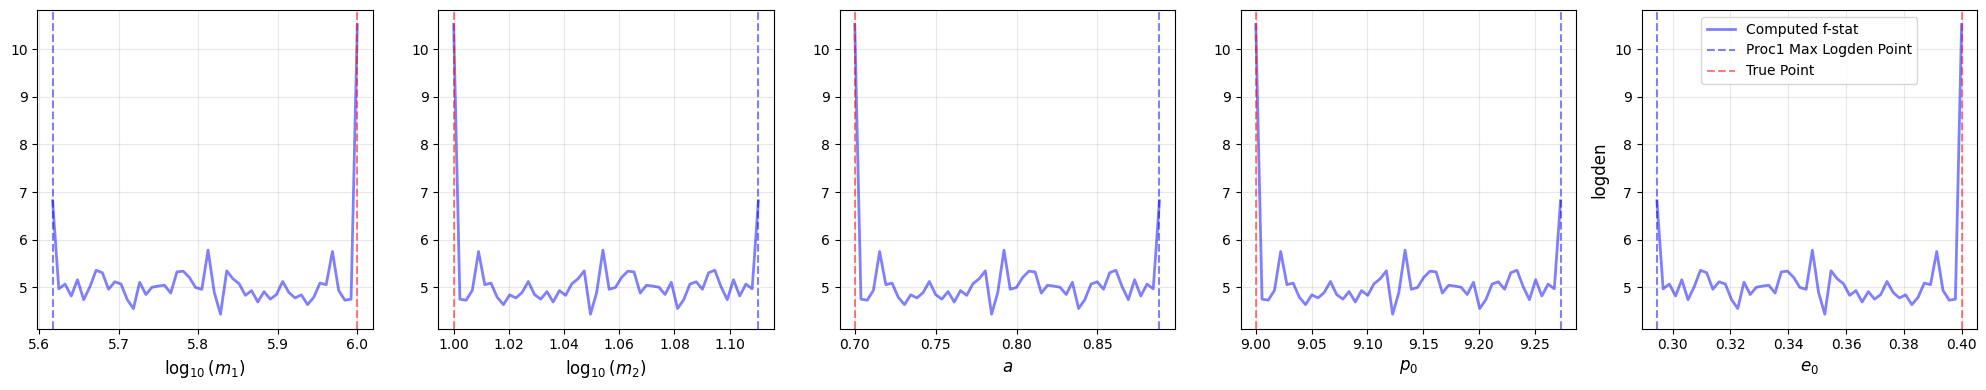

In [27]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


Initializing timemax...
Initializing phasemax...
Initializing tmXonly...
Initializing pure...
All initialized.
Evaluating timemax...
Evaluating phasemax...
Evaluating tmXonly...
Evaluating pure...
Done.


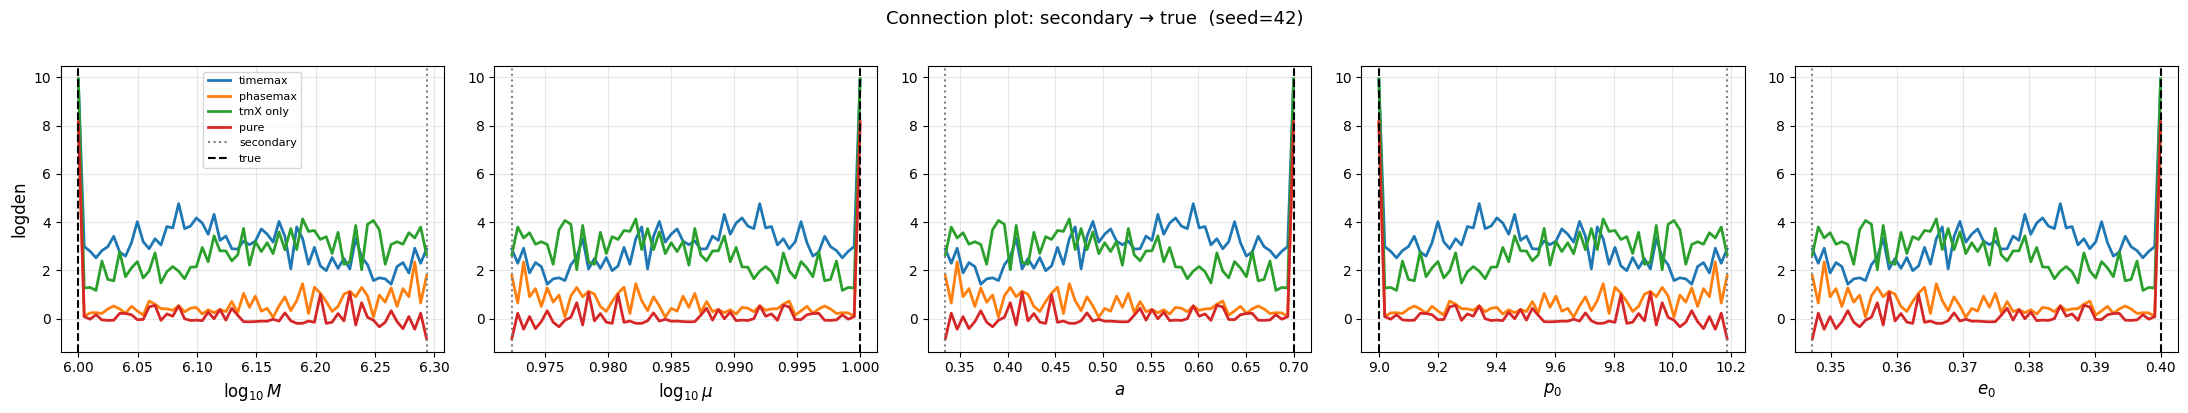

In [28]:
import importlib
import numpy as np
import matplotlib.pyplot as plt

# ── re-use existing setup (params_star, waveform_response, gwf, xI0, dist, etc.)
# ── all 4 loglike variants share the same signal (same seed=42)

import loglike_timemax_noise
import loglike_phasemax_noise
import loglike_tmXonly_noise
import loglike_pure_noise

ll_kwargs = dict(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)

print("Initializing timemax...")
ll_tm   = loglike_timemax_noise.LogLike(**ll_kwargs)
print("Initializing phasemax...")
ll_pm   = loglike_phasemax_noise.LogLike(**ll_kwargs)
print("Initializing tmXonly...")
ll_tmX  = loglike_tmXonly_noise.LogLike(**ll_kwargs)
print("Initializing pure...")
ll_pure = loglike_pure_noise.LogLike(**ll_kwargs)
print("All initialized.")

def make_log_density(ll_obj):
    """Wrap a LogLike object into a batched log_density function."""
    def _ld(params):
        params = np.asarray(params)
        out = np.zeros(params.shape[0])
        for i in range(params.shape[0]):
            logm1, logm2, a, p0, e0 = params[i]
            try:
                val = ll_obj(np.array([
                    10**logm1, 10**logm2, a, p0, e0,
                    xI0, dist, qS, phiS, qK, phiK,
                    Phi_phi0, Phi_theta0, Phi_r0
                ]))
            except Exception:
                val = -np.inf
            out[i] = val
        return out
    return _ld

ld_tm   = make_log_density(ll_tm)
ld_pm   = make_log_density(ll_pm)
ld_tmX  = make_log_density(ll_tmX)
ld_pure = make_log_density(ll_pure)

# ── connection line: secondary → true ─────────────────────────────────────────
secondary_pt = np.array([6.29332246, 0.97236086, 0.3347499, 10.18644061, 0.34722833])
true_pt      = np.array([6.0, 1.0, 0.7, 9.0, 0.4])

n_points = 60
t_vals = np.linspace(0, 1, n_points)
# line_pts[dim, n_points]
line_pts = secondary_pt[:, None] + t_vals * (true_pt - secondary_pt)[:, None]

print("Evaluating timemax..."); ld_line_tm   = ld_tm(line_pts.T)
print("Evaluating phasemax..."); ld_line_pm   = ld_pm(line_pts.T)
print("Evaluating tmXonly..."); ld_line_tmX  = ld_tmX(line_pts.T)
print("Evaluating pure...");    ld_line_pure = ld_pure(line_pts.T)
print("Done.")

# ── plot ───────────────────────────────────────────────────────────────────────
variants = [
    ('timemax',   ld_line_tm,   'C0'),
    ('phasemax',  ld_line_pm,   'C1'),
    ('tmX only',  ld_line_tmX,  'C2'),
    ('pure',      ld_line_pure, 'C3'),
]

param_labels = [r'$\log_{10}M$', r'$\log_{10}\mu$', r'$a$', r'$p_0$', r'$e_0$']

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)

for dim in range(5):
    ax = axes[dim]
    for name, ld_line, color in variants:
        ax.plot(line_pts[dim], ld_line, '-', color=color, lw=2, label=name)
    ax.axvline(secondary_pt[dim], color='gray',  ls=':', lw=1.5, label='secondary')
    ax.axvline(true_pt[dim],      color='black', ls='--', lw=1.5, label='true')
    ax.set_xlabel(param_labels[dim], fontsize=12)
    ax.grid(True, alpha=0.3)
    if dim == 0:
        ax.set_ylabel('logden', fontsize=12)

axes[0].legend(fontsize=8, loc='best')
plt.suptitle('Connection plot: secondary → true  (seed=42)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()